# Data Retrieval

In [ ]:
import pandas as pd
from datetime import *
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import plotly.graph_objects as go
from scipy.signal import find_peaks as fp

# Constants
global WORKING_DIRECTORY,RAWDATAFILES,SUPPORTED_FILEFORMATS,RAW_Data_DIR,MERGE_FILES

SUPPORTED_FILEFORMATS={"CSV":pd.read_csv,"TXT":pd.read_fwf,"JSON":pd.read_json,"XML":pd.read_xml,"XLSX":pd.read_excel,"XLS":pd.read_excel}
COL_Prefixes ={"HeartRate":"HR_","Metadata":"MD_","WatchAccelerometer":"ACC_", "WatchGravity":"G_","WatchGyroscope":"GYRO_","WatchOrientation":"OR_","WatchTotalAcceleration":"TACC_","WatchMagnetometer":"MAG_"}

RAWDATAFILES={}

MERGE_FILES=1


# Get the current working directory
cwd = os.getcwd()
WORKING_DIRECTORY = os.path.dirname(os.path.dirname(cwd)) #Parent directory
print("The current working directory is:", WORKING_DIRECTORY)

DATA_DIRECTORY = os.path.join(WORKING_DIRECTORY,"Project\\Data")
print("The data directory is:", DATA_DIRECTORY)

RAW_Data_DIR=  os.path.join(DATA_DIRECTORY,"01-raw")
PREPROCESS_Data_DIR=  os.path.join(DATA_DIRECTORY,"02-preprocessed")
FEATURES_Data_DIR=  os.path.join(DATA_DIRECTORY,"03-features")
PREDICTIONS_Data_DIR=  os.path.join(DATA_DIRECTORY,"04-predictions")

#import annotations
train_df= pd.read_excel(os.path.join(RAW_Data_DIR,"Training Notes.Xlsx"))
train_df

## Load all files

In [ ]:
#refurbished from 1. module
def loadfile(filename):
    """
    Arguments
    filename: must be full unc path
    """
    try:
        global RAWDATAFILES, MERGE_FILES
        parent_folder= os.path.abspath(os.path.join(filename, os.pardir)).split("\\")[-1]
        base_name = os.path.basename(filename).split(".")[0]
        #print(base_name)
        #Choose respective reader according to filetype
        df=SUPPORTED_FILEFORMATS[filename.upper().split(".")[-1]](filename)
        #df.info()        
        if MERGE_FILES==1:
            if base_name in RAWDATAFILES:
                RAWDATAFILES[base_name] = pd.concat([RAWDATAFILES[base_name], df.copy()], axis=0,join="outer")
            else:
                RAWDATAFILES[base_name] = df.copy()
        else:
            #Append the data frame to the global dictionary for further usage
            RAWDATAFILES[parent_folder + ":" + base_name] = df.copy()
        
        print(f"File {base_name} successfully loaded.")
        
    except Exception as e:  
        print(f"Could not load file: {filename}. Error: {e}") 

#Load all files
for folder in [f.path for f in os.scandir(RAW_Data_DIR) if f.is_dir()]:
    source = os.listdir(folder)
    print(source)
    filteredlist = [x for x in source if x.upper().split(".")[-1] in list(SUPPORTED_FILEFORMATS.keys()) ]
    for idx, file in enumerate(filteredlist):
        if (file.find("Mag")!=-1):
            continue
        loadfile(os.path.join( folder,file))

#Rename columns
for k in RAWDATAFILES:
    RAWDATAFILES[k].columns = [COL_Prefixes[k] + a for a in RAWDATAFILES[k].columns]

## Combine all Sensors

In [ ]:
RAW_DF = pd.DataFrame([],columns=["time"])
RAW_DF.set_index(["time"], inplace=True)
MD_DF = pd.DataFrame()

#print(RAWDATAFILES)
for element in RAWDATAFILES:
    #RAWDATAFILES[element].info()
    if element!="Metadata":
        #Wintertime(+1)
        RAWDATAFILES[element]["time"] = pd.to_datetime(RAWDATAFILES[element][COL_Prefixes[element]+"time"])+ pd.DateOffset(hours=1)
        RAWDATAFILES[element].set_index("time", inplace=True)
        RAW_DF= RAW_DF.join(RAWDATAFILES[element], how='outer')
    else:
        #Wintertime(+1)
        RAWDATAFILES[element]["time"] = pd.to_datetime(RAWDATAFILES[element][COL_Prefixes[element]+"recording epoch time"])+ pd.DateOffset(hours=1)
        RAWDATAFILES[element].set_index("time", inplace=True)
        MD_DF= RAWDATAFILES[element].copy()

#RAW_DF["time"] = pd.to_datetime(RAW_DF["time"])
#RAW_DF.set_index(["time"],inplace=True)
RAW_DF.sort_index(inplace=True)

In [ ]:
RAW_DF.info()
RAW_DF.describe()

In [ ]:
#Check Distribution of each potential Feature
sns.set_theme(style="whitegrid")
for element in RAW_DF.columns:
    if((element.find("time")==-1) & (element.find("seconds")==-1)):
        print(element)
        sns.histplot(data=RAW_DF, x=element,bins=20)
        plt.show()

In [ ]:
print(RAW_DF[RAW_DF.GYRO_x.isna()!=True][["GYRO_x"]])

In [ ]:
# Plotly Interactive 
def plotlines(df,StartPlotTime,EndPlotTime):
    # Derrive Masks for Plotting
    maskTime = (df.index >= StartPlotTime) & (df.index <= EndPlotTime)
    #maskTime2 = (train_df["time"] >= StartPlotTime) & (train_df["time"] <= EndPlotTime)

    fig3 = go.Figure(layout_yaxis_range=[-4,4],layout_xaxis_range=[StartPlotTime.strftime("YYYY-mm-dd") ,EndPlotTime.strftime("YYYY-mm-dd")], layout = dict(title='Galaxy Watch 6', xaxis=dict(type='date'),width=1600, height=800 ))

    #create dict with unique color values
    color_dict={}
    x=0
    for col in df.columns:
        if col not in color_dict:
            color_dict[col]=x
            x += 1
            
    #create color list
    color_list=[]
    for col in df.columns:
        color_list.append(color_dict[col])

    fig3.update_layout(hovermode="x unified")

    buttonlist=[]

    for element in RAW_DF.columns:
        #if ((element.find("HR_bpm")>-1) | (element.find("TACC")>-1)):
        #    continue
        if (element.find("time") ==-1) & (element.find("seconds") ==-1):
            fig3.add_trace(go.Scatter(x=df[maskTime].index, y=df[maskTime][element],mode="lines", name=element,connectgaps=True,stackgaps='infer zero',marker_color=color_list,marker_colorscale="Rainbow"))
            buttonlist.append(element)
            
    # Layout Settings
    fig3.update_yaxes( type="linear", range=(-4,4)) #, autorange= True)#, constrain="domain")
    fig3.update_xaxes(
        rangeslider_visible=True,
        rangeselector=dict(
            buttons=list([
                dict(count=900, label="15min", step="second", stepmode="backward"),
                dict(count=60, label="1h", step="minute", stepmode="backward"),
                dict(count=24, label="1d", step="hour", stepmode="todate"),
                dict(count=7, label="1week", step="day", stepmode="backward"),
                dict(step="all")
            ])
        )
    )

    # Interactive Time Range Slider & Sensor Selection
    fig3.update_xaxes(rangeslider_yaxis_range=[0,160],rangeslider_yaxis_rangemode="fixed")
    fig3.update_layout(
        autosize=True,
        margin=dict(
            l=50,
            r=50,
            b=100,
            t=100,
            pad=4
        )
        ,
        updatemenus=[
            dict(
            buttons=list([   
                dict(label="None",
                        method="update",
                        args=[{"visible": [True,True, True, True, True,True, True, True, True,True, True, True, True,True, True, True, True,True,True,True]},
                            {"title": buttonlist}]),
                dict(label = 'show HR',
                    method = 'update',
                    args = [{"visible": [True,False, False, False, False,False, False, False, False,False, False, False, False,False, False, False, False,False,False,False]},
                            {'title': buttonlist}]),
                dict(label = 'show OR',
                    method = 'update',
                    args = [{"visible": [False,False, False, False, False,False, False, False, False,False, True, True, True,True, True, True, True,False,False,False]},
                            {'title': buttonlist}]),
                dict(label = 'show Acceleration',
                    method = 'update',
                    args = [{"visible": [False,True, True, True, False,False, False, False, False,False, False, False, False,False, False, False, False,False,False,False]},
                            {'title': buttonlist}]),
                
                dict(label = 'show Gravity + Gyro',
                    method = 'update',
                    args = [{"visible": [False,False, False, False, True,True, True, True, True,True, False, False, False,False, False, False, False,False,False,False]},
                            {'title': buttonlist}])
            ])
        )]
        )
    fig3.show()

In [ ]:
# Plot Raw Data
# Please set the Plot Range within 1 day to avoid buffer overflows (above section)
StartPlotTime=datetime(2025, 12,22,9,0,0)
EndPlotTime=datetime(2025, 12,22,22,0,0) #datetime.now()
plotlines(RAW_DF,StartPlotTime,EndPlotTime)

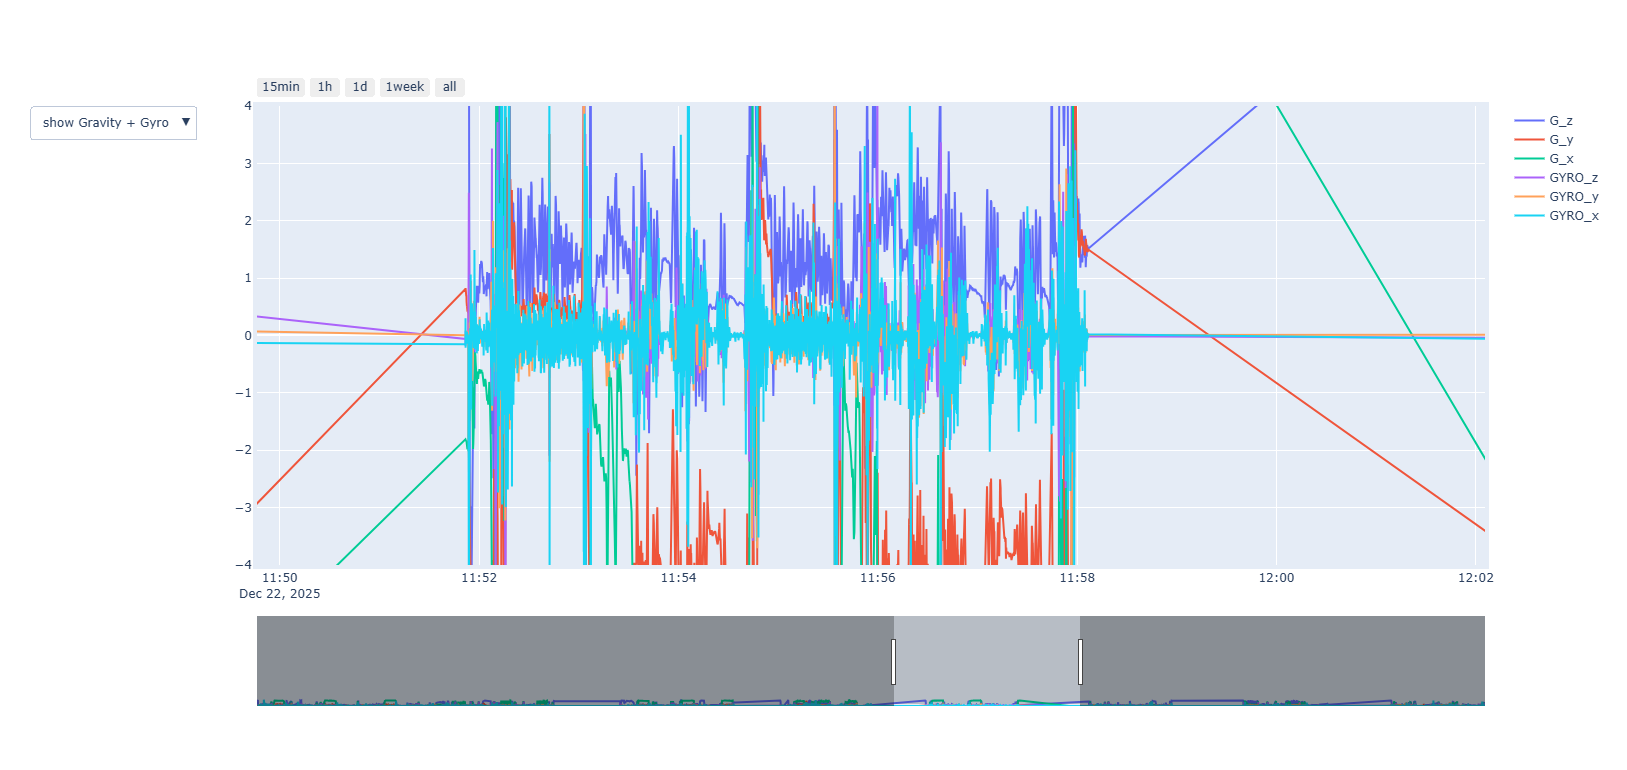

In [ ]:
#Resampling 4hz (as source varies over time)
PREPROC_DF=RAW_DF.resample('250ms').mean()
PREPROC_DF.sample(100)

In [ ]:
# Plot resampled data (also used for labeling in Preprocessing)
StartPlotTime=datetime(2025, 12,27,9,0,0)
EndPlotTime=datetime(2025, 12,27,21,0,0)#datetime.now()
plotlines(PREPROC_DF,StartPlotTime,EndPlotTime)

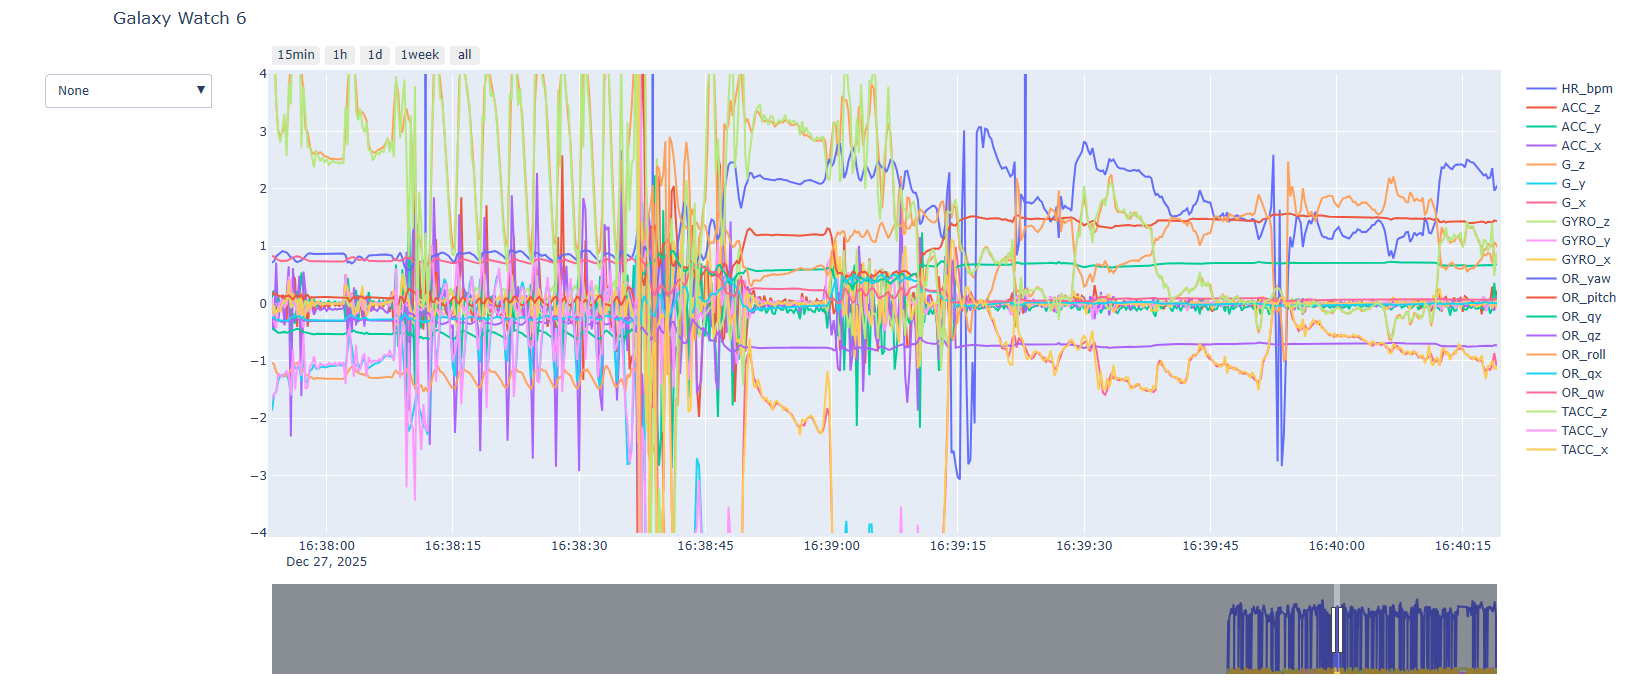

In [ ]:
#Final Check
PREPROC_DF.sample(100)

In [ ]:
#Extract data for Preprocessing
PREPROC_DF.to_pickle(os.path.join(PREPROCESS_Data_DIR,"250MS_Resampled.pkl"))

In [ ]:
# run lines in terminal to convert into html
print(f"cas_gpu_venv\\Scripts\\activate.bat")
print(f"jupyter-nbconvert --to html \"0_Module\\M3_Machine_Learning\\Project\\notebooks\\{os.path.basename(globals()['__vsc_ipynb_file__'])}\"")